## Libraries and Data Loading

In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt

In [2]:
df = pl.read_csv("../data/collaborative_filtering/train.csv")
df.head(5)

user,item,rating
i64,i64,f64
1,25715,7.0
1,25716,10.0
5,25851,9.0
6,25923,5.0
7,25924,6.0


# Basic Info about the dataset

In [3]:
duckdb.sql("""
    SELECT AVG(rating) AS avg_rating, COUNT(*) AS num_ratings, max(rating) AS max_rating, min(rating) AS min_rating
    FROM df
           """)

┌───────────────────┬─────────────┬────────────┬────────────┐
│    avg_rating     │ num_ratings │ max_rating │ min_rating │
│      double       │    int64    │   double   │   double   │
├───────────────────┼─────────────┼────────────┼────────────┤
│ 7.604666056958993 │      390351 │       10.0 │        1.0 │
└───────────────────┴─────────────┴────────────┴────────────┘

In [4]:
duckdb.sql("""    
    SELECT COUNT(DISTINCT user) AS num_users
    FROM df
           """)

┌───────────┐
│ num_users │
│   int64   │
├───────────┤
│     73456 │
└───────────┘

In [5]:
duckdb.sql("""    
    SELECT COUNT(DISTINCT item) AS num_items
    FROM df
           """)

┌───────────┐
│ num_items │
│   int64   │
├───────────┤
│    171171 │
└───────────┘

# How many votes has a rating

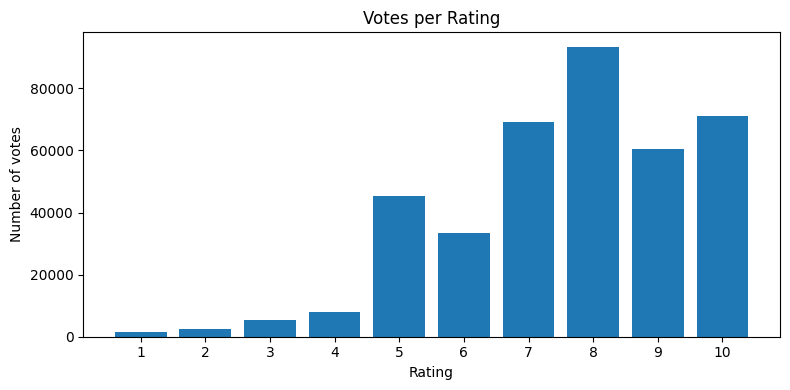

In [6]:
rating_votes = duckdb.sql("""
    SELECT rating, COUNT(*) AS num_votes
    FROM df
    GROUP BY rating
    ORDER BY rating
""").pl()

plt.figure(figsize=(8, 4))
plt.bar(rating_votes["rating"].to_list(), rating_votes["num_votes"].to_list())
plt.xlabel("Rating")
plt.ylabel("Number of votes")
plt.title("Votes per Rating")
plt.xticks(rating_votes["rating"].to_list())
plt.tight_layout()
plt.show()

# Metrics by user

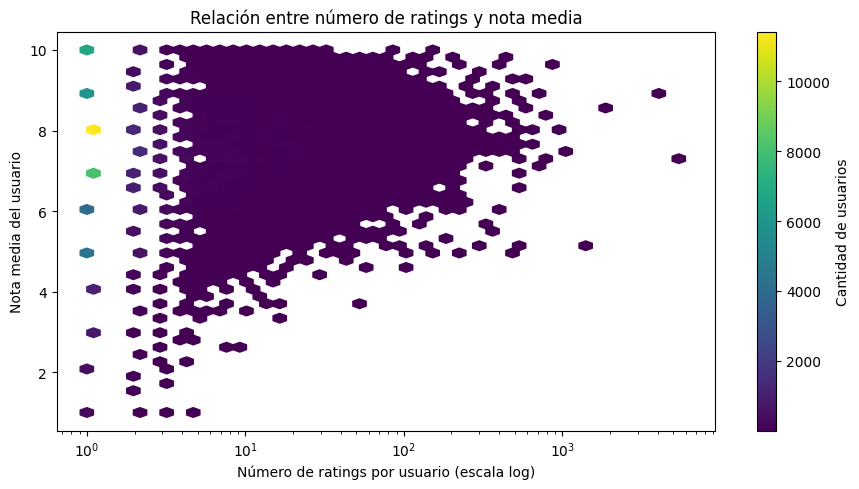

In [7]:
user_metrics = duckdb.sql("""
    SELECT
        user,
        COUNT(*) AS num_ratings,
        AVG(rating) AS avg_rating
    FROM df
    GROUP BY user
""").pl()

plt.figure(figsize=(9, 5))
hb = plt.hexbin(
    user_metrics["num_ratings"].to_numpy(),
    user_metrics["avg_rating"].to_numpy(),
    gridsize=45,
    cmap="viridis",
    mincnt=1,
    xscale="log"
)
plt.colorbar(hb, label="Cantidad de usuarios")
plt.xlabel("Número de ratings por usuario (escala log)")
plt.ylabel("Nota media del usuario")
plt.title("Relación entre número de ratings y nota media")
plt.tight_layout()
plt.show()

# duckdb.sql("""
#            SELECT user, COUNT(*) AS num_ratings, AVG(rating) AS avg_rating
#               FROM df   

#                 GROUP BY user
#                 ORDER BY num_ratings DESC
#             """       
           
#            ).pl()

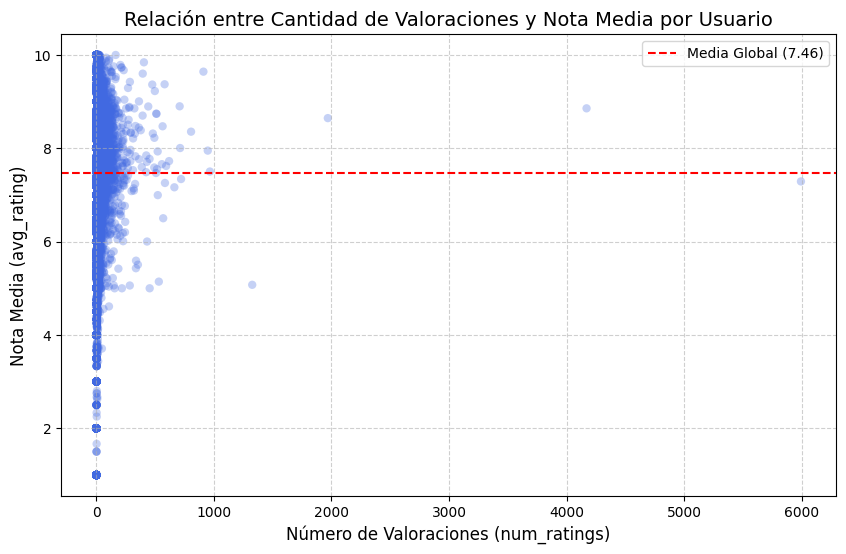

In [8]:
# Extraemos las columnas del DataFrame de Polars
x = user_metrics['num_ratings']
y = user_metrics['avg_rating']

plt.figure(figsize=(10, 6))
# alpha=0.3 hace que los puntos sean semitransparentes
plt.scatter(x, y, alpha=0.3, color='royalblue', edgecolor='none')

plt.title('Relación entre Cantidad de Valoraciones y Nota Media por Usuario', fontsize=14)
plt.xlabel('Número de Valoraciones (num_ratings)', fontsize=12)
plt.ylabel('Nota Media (avg_rating)', fontsize=12)

# Añadimos una línea horizontal con la media global de todas las notas para tener referencia
plt.axhline(y.mean(), color='red', linestyle='--', label=f'Media Global ({y.mean():.2f})')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

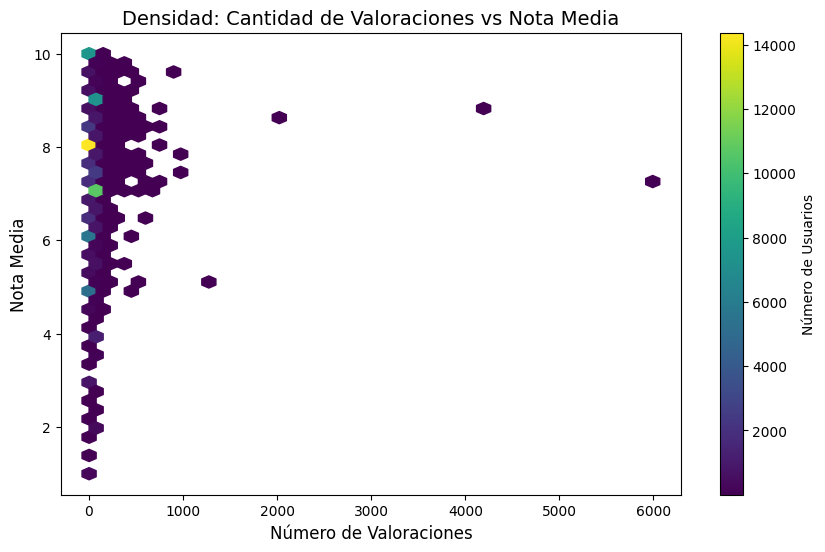

In [9]:
x = user_metrics['num_ratings']
y = user_metrics['avg_rating']

plt.figure(figsize=(10, 6))
# gridsize define el tamaño de los hexágonos (mayor número = hexágonos más pequeños)
# mincnt=1 evita dibujar hexágonos vacíos
hb = plt.hexbin(x, y, gridsize=40, cmap='viridis', mincnt=1)

plt.title('Densidad: Cantidad de Valoraciones vs Nota Media', fontsize=14)
plt.xlabel('Número de Valoraciones', fontsize=12)
plt.ylabel('Nota Media', fontsize=12)

# Añadimos la barra de color lateral para entender la escala de densidad
cb = plt.colorbar(hb)
cb.set_label('Número de Usuarios')

plt.show()

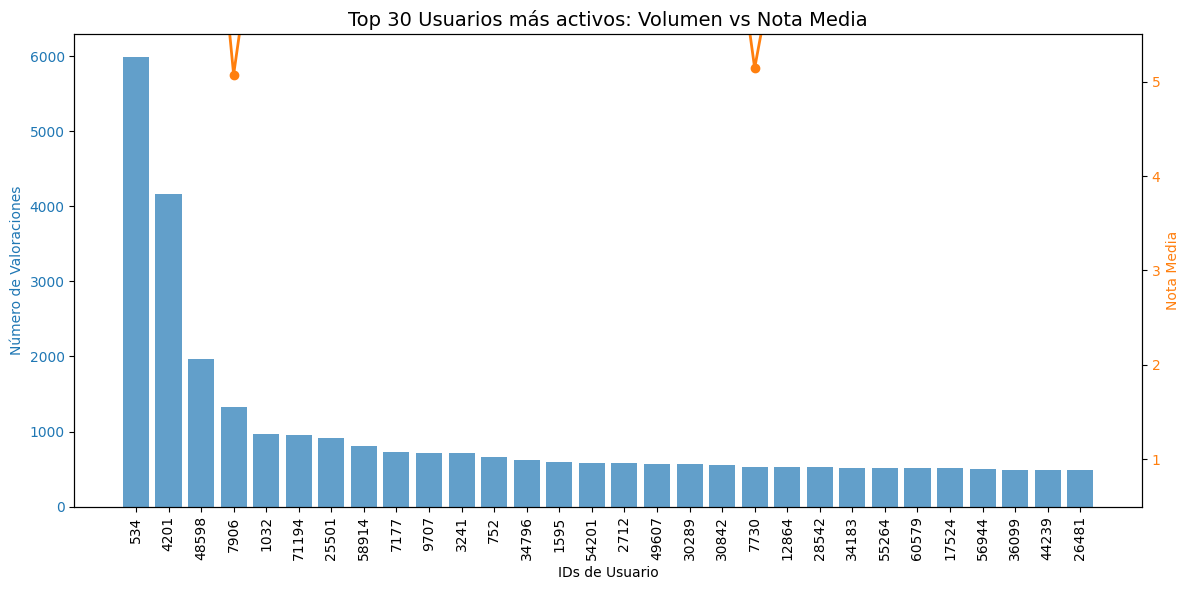

In [10]:
top_users = user_metrics.sort('num_ratings', descending=True).head(30)

users = top_users['user'].to_list() # Convertir a lista para los labels si es necesario
counts = top_users['num_ratings']
avgs = top_users['avg_rating']

# Crear figura y el primer eje (para las barras)
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('IDs de Usuario')
ax1.set_ylabel('Número de Valoraciones', color=color)
ax1.bar(range(len(users)), counts, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(users)))
ax1.set_xticklabels(users, rotation=90) # Rotar IDs para que se lean

# Crear el segundo eje que comparte el mismo eje X
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Nota Media', color=color)  
# Dibujamos la nota media con puntos y líneas
ax2.plot(range(len(users)), avgs, color=color, marker='o', linestyle='-', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Limitar el eje Y de la nota para que la perspectiva sea clara (ej. notas de 1 a 5)
ax2.set_ylim(0.5, 5.5) 

plt.title('Top 30 Usuarios más activos: Volumen vs Nota Media', fontsize=14)
fig.tight_layout()  # Ajusta el layout para que no se corten las etiquetas
plt.show()

# Positive VS Negative Ratings

In [11]:
df_positiveness = duckdb.sql("""
    SELECT user, item, rating, IF(rating >= 4, 'Positive', 'Negative') AS rating_type
    FROM df
    """).pl()
df_positiveness.head(5)

user,item,rating,rating_type
i64,i64,f64,str
1,25715,7.0,"""Positive"""
1,25716,10.0,"""Positive"""
5,25851,9.0,"""Positive"""
6,25923,5.0,"""Positive"""
7,25924,6.0,"""Positive"""


In [12]:
duckdb.sql("""
            SELECT rating_type, COUNT(*) AS num_ratings
            FROM df_positiveness
            GROUP BY rating_type
           """)

┌─────────────┬─────────────┐
│ rating_type │ num_ratings │
│   varchar   │    int64    │
├─────────────┼─────────────┤
│ Negative    │        9493 │
│ Positive    │      380858 │
└─────────────┴─────────────┘

In [13]:
df_posi = duckdb.sql("""
        SELECT
            user,
            SUM(CASE WHEN rating_type = 'Positive' THEN 1 ELSE 0 END) AS num_positive_ratings,
            SUM(CASE WHEN rating_type = 'Negative' THEN 1 ELSE 0 END) AS num_negative_ratings,
            (num_positive_ratings * 100.0 / NULLIF(num_positive_ratings + num_negative_ratings, 0)) AS positive_percentage,
            num_positive_ratings + num_negative_ratings AS total_ratings
        FROM df_positiveness
        GROUP BY user
        ORDER BY user
           """).pl()
df_posi.head(5)

user,num_positive_ratings,num_negative_ratings,positive_percentage,total_ratings
i64,"decimal[38,0]","decimal[38,0]",f64,"decimal[38,0]"
1,2,0,100.0,2
5,1,0,100.0,1
6,1,0,100.0,1
7,6,0,100.0,6
9,4,0,100.0,4


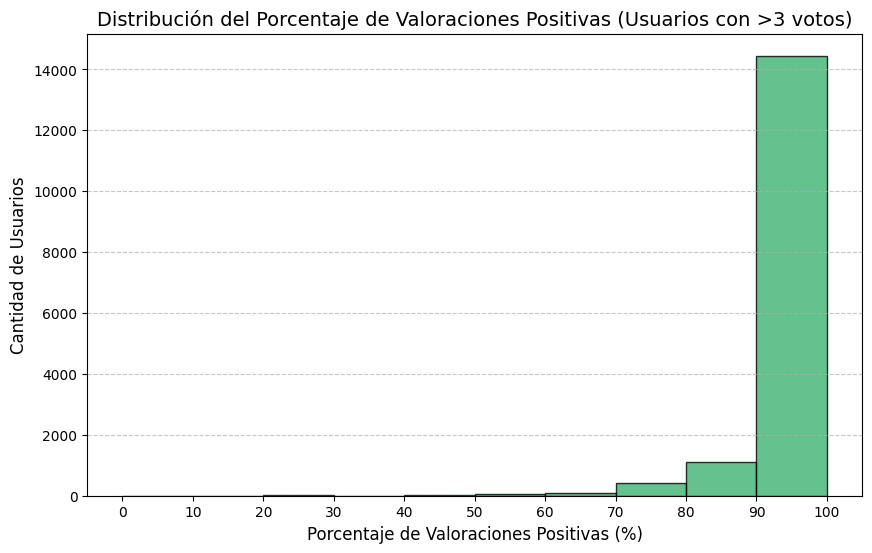

In [14]:
# Filtramos (opcionalmente) usuarios con más de 3 votos para evitar el sesgo de la primera valoración
df_filtered = df_posi.filter(df_posi['total_ratings'] > 3)
porcentajes = df_filtered['positive_percentage'].to_list()

plt.figure(figsize=(10, 6))
# Creamos el histograma con bins de 10 en 10
plt.hist(porcentajes, bins=10, range=(0, 100), color='mediumseagreen', edgecolor='black', alpha=0.8)

plt.title('Distribución del Porcentaje de Valoraciones Positivas (Usuarios con >3 votos)', fontsize=14)
plt.xlabel('Porcentaje de Valoraciones Positivas (%)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.xticks(range(0, 101, 10)) # Marcas en el eje X de 10 en 10
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

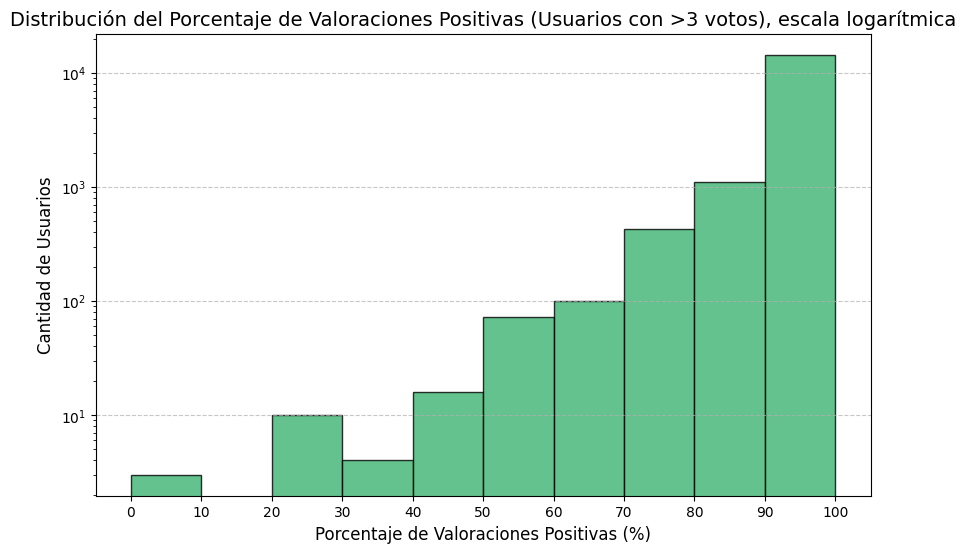

In [15]:
# Filtramos (opcionalmente) usuarios con más de 3 votos para evitar el sesgo de la primera valoración
df_filtered = df_posi.filter(df_posi['total_ratings'] > 3)
porcentajes = df_filtered['positive_percentage'].to_list()

plt.figure(figsize=(10, 6))
# Creamos el histograma con bins de 10 en 10
plt.hist(porcentajes, bins=10, range=(0, 100), color='mediumseagreen', edgecolor='black', alpha=0.8)

# --- CAMBIO AQUÍ ---
plt.yscale('log') 
# -------------------

plt.title('Distribución del Porcentaje de Valoraciones Positivas (Usuarios con >3 votos), escala logarítmica', fontsize=14)
plt.xlabel('Porcentaje de Valoraciones Positivas (%)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.xticks(range(0, 101, 10)) # Marcas en el eje X de 10 en 10
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

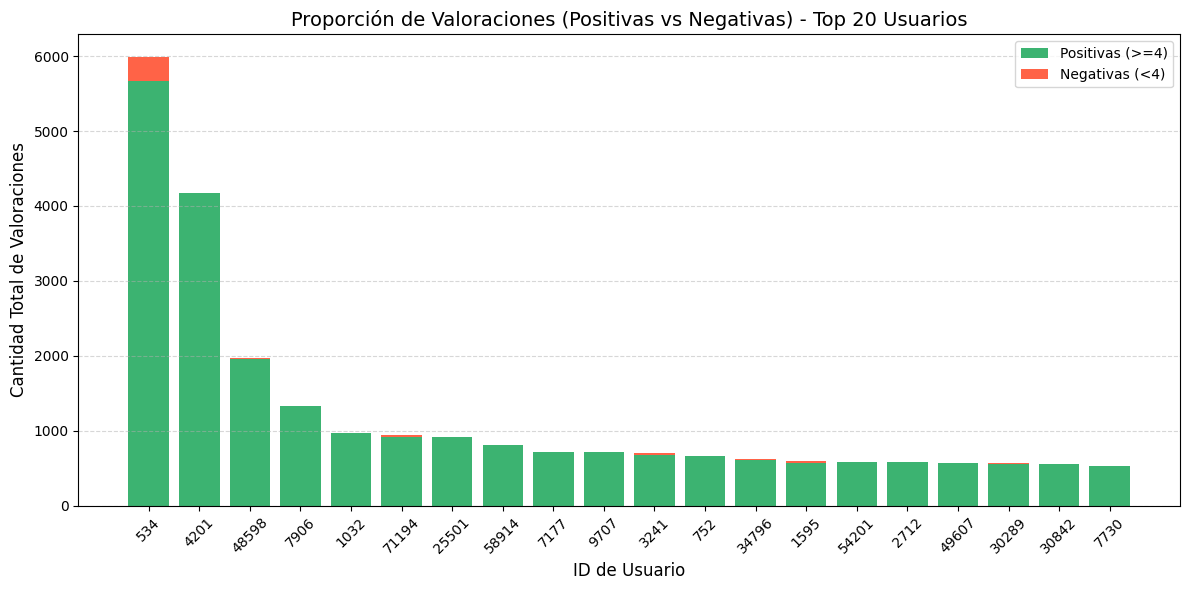

In [16]:
# Sacamos el top 20 de usuarios con más valoraciones en total
top_users = df_posi.sort('total_ratings', descending=True).head(20)

users_ids = [str(uid) for uid in top_users['user'].to_list()] # Convertimos a string para el eje X
pos_counts = top_users['num_positive_ratings'].to_list()
neg_counts = top_users['num_negative_ratings'].to_list()

plt.figure(figsize=(12, 6))

# Barra de positivos
plt.bar(users_ids, pos_counts, color='mediumseagreen', label='Positivas (>=4)')
# Barra de negativos apilada encima (usando el parámetro 'bottom')
plt.bar(users_ids, neg_counts, bottom=pos_counts, color='tomato', label='Negativas (<4)')

plt.title('Proporción de Valoraciones (Positivas vs Negativas) - Top 20 Usuarios', fontsize=14)
plt.xlabel('ID de Usuario', fontsize=12)
plt.ylabel('Cantidad Total de Valoraciones', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

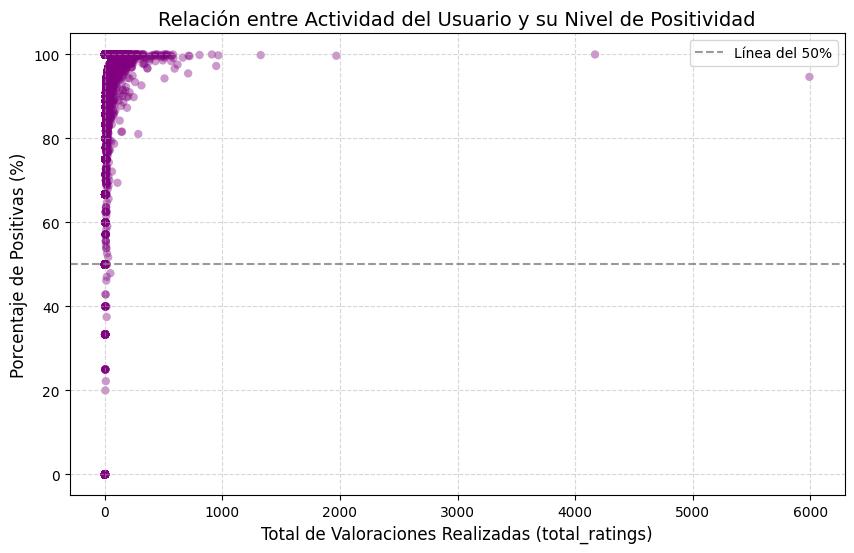

In [17]:
x_total = df_posi['total_ratings'].to_list()
y_porcentaje = df_posi['positive_percentage'].to_list()

plt.figure(figsize=(10, 6))

# Dibujamos los puntos
plt.scatter(x_total, y_porcentaje, color='purple', alpha=0.4, edgecolors='none')

plt.title('Relación entre Actividad del Usuario y su Nivel de Positividad', fontsize=14)
plt.xlabel('Total de Valoraciones Realizadas (total_ratings)', fontsize=12)
plt.ylabel('Porcentaje de Positivas (%)', fontsize=12)

# Opcional: Escala logarítmica si tienes usuarios con miles de votos y otros con solo 1
# plt.xscale('log')

# Línea horizontal del 50% para ver rápidamente quién es más positivo que negativo
plt.axhline(50, color='gray', linestyle='--', alpha=0.8, label='Línea del 50%')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Estudio de items

In [18]:
df_items = duckdb.sql("""
    SELECT item, COUNT(*) AS num_ratings, AVG(rating) AS avg_rating
    FROM df 
    GROUP BY item
    ORDER BY num_ratings DESC
           """).pl()
df_items.head(5)

item,num_ratings,avg_rating
i64,i64,f64
26361,707,8.18529
25871,487,8.435318
295,403,4.280397
26207,333,8.408408
28197,320,7.8875


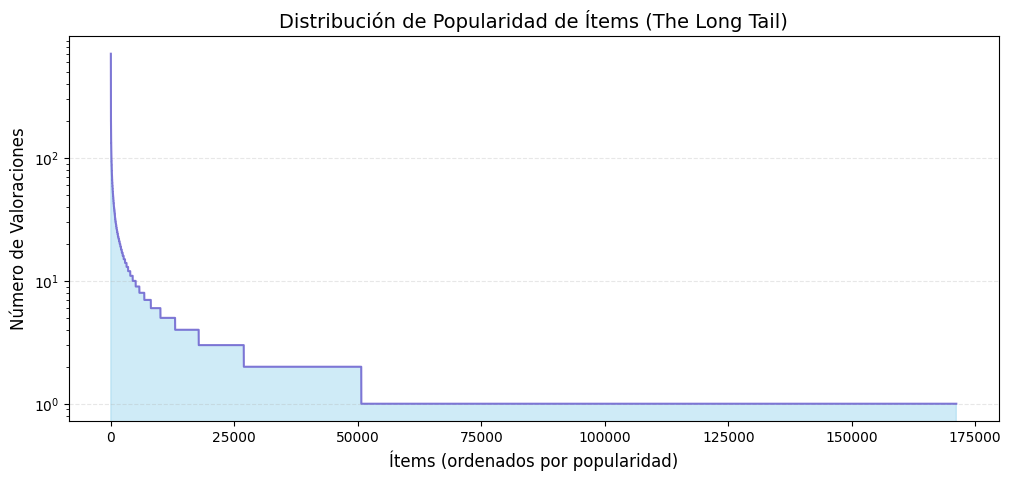

In [19]:
# Tomamos los datos ordenados (ya vienen así de tu SQL)
counts = df_items['num_ratings'].to_list()

plt.figure(figsize=(12, 5))
plt.fill_between(range(len(counts)), counts, color="skyblue", alpha=0.4)
plt.plot(range(len(counts)), counts, color="Slateblue", alpha=0.8)

plt.title('Distribución de Popularidad de Ítems (The Long Tail)', fontsize=14)
plt.xlabel('Ítems (ordenados por popularidad)', fontsize=12)
plt.ylabel('Número de Valoraciones', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Opcional: Escala logarítmica en Y si la diferencia entre el top 1 y el resto es masiva
plt.yscale('log')

plt.show()

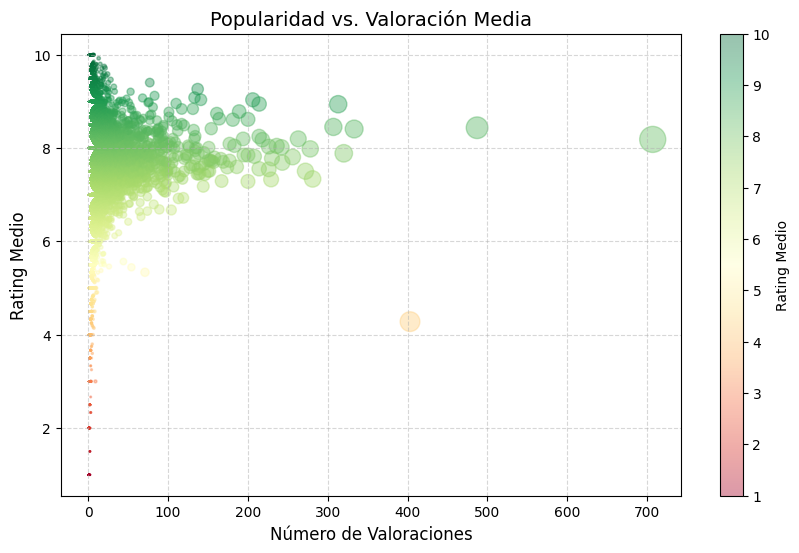

In [20]:
x = df_items['num_ratings']
y = df_items['avg_rating']

plt.figure(figsize=(10, 6))
# El tamaño del punto (s) depende de num_ratings para enfatizar
plt.scatter(x, y, alpha=0.4, c=y, cmap='RdYlGn', s=x*0.5) 

plt.title('Popularidad vs. Valoración Media', fontsize=14)
plt.xlabel('Número de Valoraciones', fontsize=12)
plt.ylabel('Rating Medio', fontsize=12)
plt.colorbar(label='Rating Medio')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

C:\Users\rahar\AppData\Local\Temp\ipykernel_19076\1868716049.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=categorias, patch_artist=True)


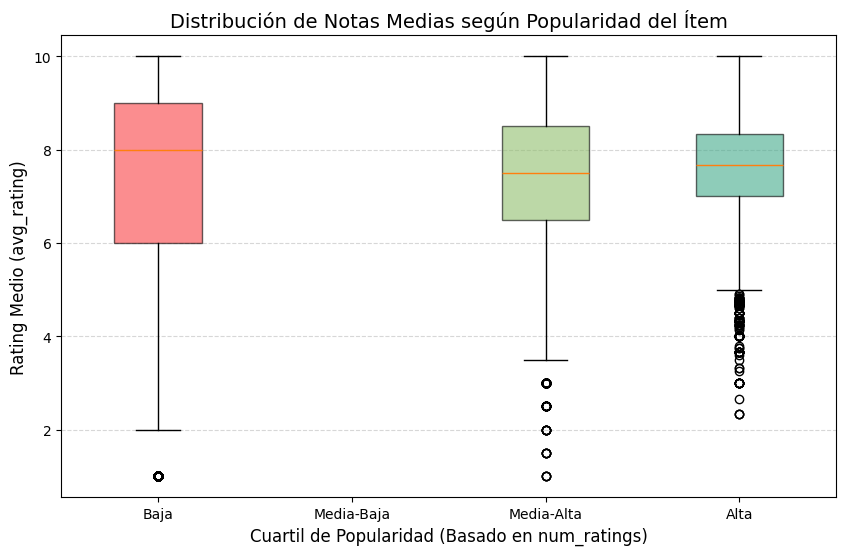

In [21]:
df_items = df_items.with_columns(
    pl.col("num_ratings")
    .qcut(4, labels=["Baja", "Media-Baja", "Media-Alta", "Alta"], allow_duplicates=True)
    .alias("pop_quartile")
)

# 2. Preparamos los datos para matplotlib (agrupando por el cuartil creado)
# Usamos un diccionario para asegurar que el orden de las etiquetas en el gráfico sea el correcto
categorias = ["Baja", "Media-Baja", "Media-Alta", "Alta"]
data_to_plot = [
    df_items.filter(pl.col("pop_quartile") == cat)["avg_rating"].to_list() 
    for cat in categorias
]

# 3. Creamos el gráfico
plt.figure(figsize=(10, 6))

# Dibujamos el boxplot
# patch_artist=True permite rellenar las cajas de color
bp = plt.boxplot(data_to_plot, labels=categorias, patch_artist=True)

# Personalizamos colores
colors = ['#f94144', '#f8961e', '#90be6d', '#43aa8b']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title('Distribución de Notas Medias según Popularidad del Ítem', fontsize=14)
plt.ylabel('Rating Medio (avg_rating)', fontsize=12)
plt.xlabel('Cuartil de Popularidad (Basado en num_ratings)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [22]:
# Calculamos métricas de dispersión por ítem
df_variance = duckdb.sql("""
    SELECT 
        item, 
        COUNT(*) AS num_ratings, 
        AVG(rating) AS avg_rating,
        STDDEV(rating) AS std_dev_rating
    FROM df 
    GROUP BY item
    HAVING num_ratings > 1  -- La varianza no existe para 1 solo voto
""").pl()

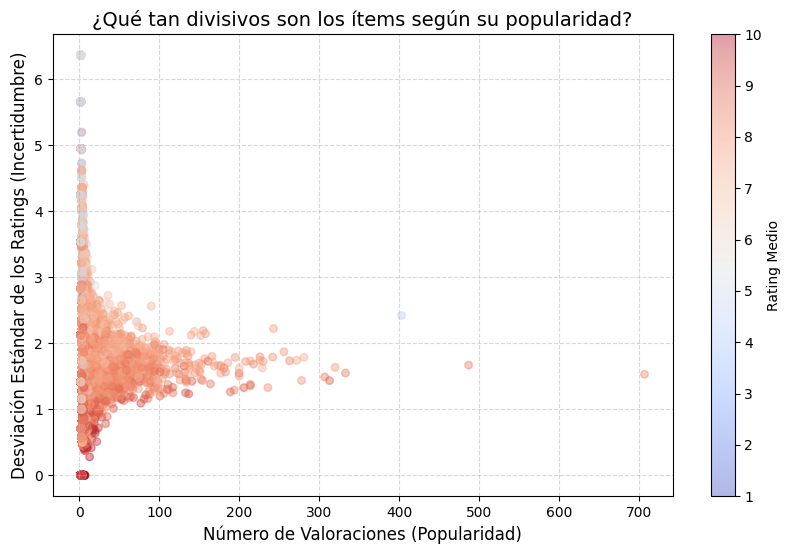

In [23]:
plt.figure(figsize=(10, 6))

# Scatter plot: Popularidad vs Desviación Estándar
plt.scatter(
    df_variance['num_ratings'], 
    df_variance['std_dev_rating'], 
    alpha=0.4, 
    c=df_variance['avg_rating'], 
    cmap='coolwarm',
    s=30
)

plt.title('¿Qué tan divisivos son los ítems según su popularidad?', fontsize=14)
plt.xlabel('Número de Valoraciones (Popularidad)', fontsize=12)
plt.ylabel('Desviación Estándar de los Ratings (Incertidumbre)', fontsize=12)
plt.colorbar(label='Rating Medio')
plt.grid(True, linestyle='--', alpha=0.5)

# Opcional: Escala logarítmica si hay blockbusters con muchísimos votos
# plt.xscale('log')

plt.show()

## Estudio bayesiano

In [24]:
# 1. Calculamos las constantes globales
m = df_items["avg_rating"].mean()
C = df_items["num_ratings"].median() # Usar la mediana es más robusto que la media

print(f"Media global (m): {m:.2f}")
print(f"Votos mínimos de confianza (C): {C}")

# 2. Aplicamos la fórmula para crear la nueva métrica
df_bayes = df_items.with_columns(
    (
        (pl.col("num_ratings") * pl.col("avg_rating") + C * m) /
        (pl.col("num_ratings") + C)
    ).alias("bayesian_rating")
)

# 3. Veamos la diferencia en el Top 10
print(df_bayes.sort("bayesian_rating", descending=True).head(10))

Media global (m): 7.50
Votos mínimos de confianza (C): 1.0
shape: (10, 5)
┌───────┬─────────────┬────────────┬──────────────┬─────────────────┐
│ item  ┆ num_ratings ┆ avg_rating ┆ pop_quartile ┆ bayesian_rating │
│ ---   ┆ ---         ┆ ---        ┆ ---          ┆ ---             │
│ i64   ┆ i64         ┆ f64        ┆ cat          ┆ f64             │
╞═══════╪═════════════╪════════════╪══════════════╪═════════════════╡
│ 93824 ┆ 13          ┆ 9.923077   ┆ Alta         ┆ 9.749679        │
│ 3088  ┆ 7           ┆ 10.0       ┆ Alta         ┆ 9.686939        │
│ 93825 ┆ 7           ┆ 10.0       ┆ Alta         ┆ 9.686939        │
│ 35795 ┆ 7           ┆ 10.0       ┆ Alta         ┆ 9.686939        │
│ 13733 ┆ 15          ┆ 9.8        ┆ Alta         ┆ 9.655969        │
│ 56700 ┆ 20          ┆ 9.75       ┆ Alta         ┆ 9.642643        │
│ 50222 ┆ 6           ┆ 10.0       ┆ Alta         ┆ 9.642216        │
│ 44765 ┆ 6           ┆ 10.0       ┆ Alta         ┆ 9.642216        │
│ 59337 ┆ 6     

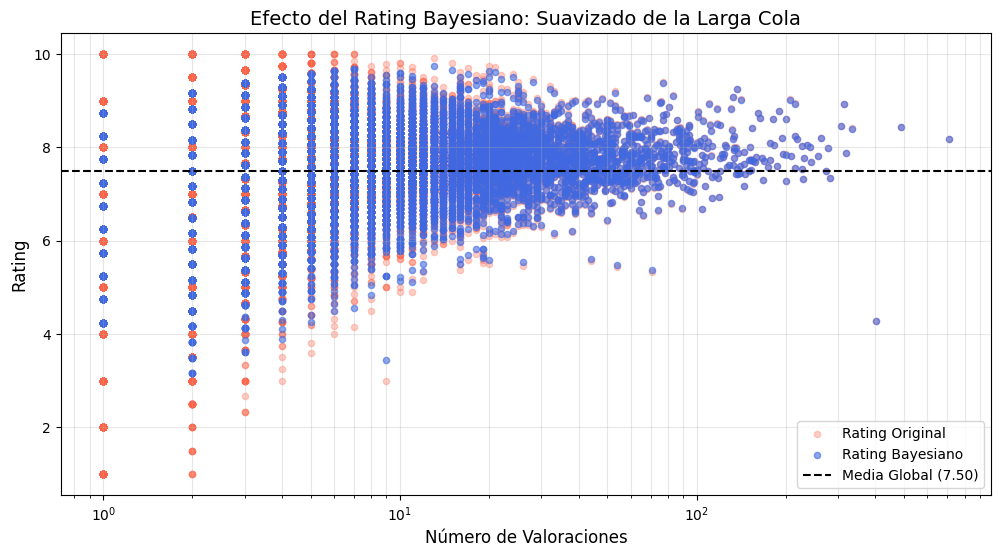

In [25]:
plt.figure(figsize=(12, 6))

# Rating Original (en rojo suave)
plt.scatter(df_bayes['num_ratings'], df_bayes['avg_rating'], 
            alpha=0.3, color='tomato', label='Rating Original', s=20)

# Rating Bayesiano (en azul)
plt.scatter(df_bayes['num_ratings'], df_bayes['bayesian_rating'], 
            alpha=0.6, color='royalblue', label='Rating Bayesiano', s=20)

plt.axhline(m, color='black', linestyle='--', label=f'Media Global ({m:.2f})')

plt.title('Efecto del Rating Bayesiano: Suavizado de la Larga Cola', fontsize=14)
plt.xlabel('Número de Valoraciones', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xscale('log') # Escala logarítmica para ver mejor la cola
plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.show()

# Estudio numero valoraciones por usuario

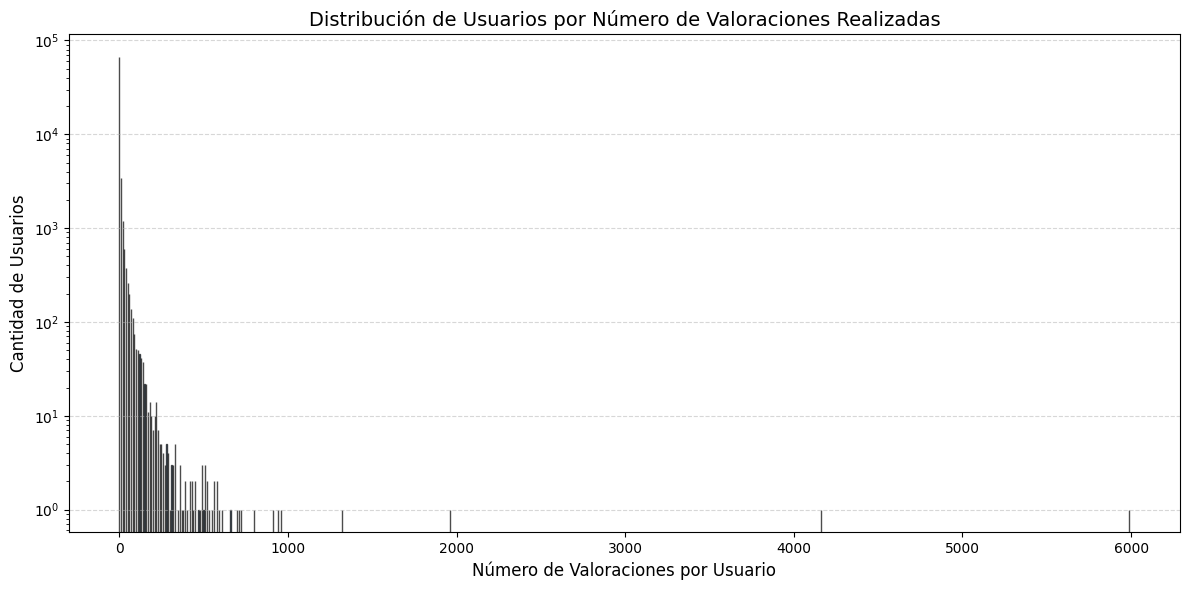

In [32]:
# Agrupar usuarios por número de valoraciones en bins de 10
user_rating_counts = duckdb.sql("""
    SELECT 
        FLOOR(num_ratings / 10) * 10 AS rating_bin,
        COUNT(*) AS num_users
    FROM user_metrics
    GROUP BY FLOOR(num_ratings / 10) * 10
    ORDER BY rating_bin
""").pl()
# user_rating_counts = duckdb.sql("""
#     SELECT num_ratings, COUNT(*) AS num_users
#     FROM user_metrics
#     GROUP BY num_ratings
#     ORDER BY num_ratings
# """).pl()

plt.figure(figsize=(12, 6))
plt.bar(user_rating_counts['rating_bin'].to_list(), user_rating_counts['num_users'].to_list(), 
        color='steelblue', alpha=0.7, edgecolor='black')

plt.title('Distribución de Usuarios por Número de Valoraciones Realizadas', fontsize=14)
plt.xlabel('Número de Valoraciones por Usuario', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.yscale('log')  # Escala logarítmica para ver mejor la cola
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Addresing the cold start problem

## Nuevos usuairos sin valoraciones previas

In [26]:
df_onlyonly = duckdb.sql("""
    SELECT *
    FROM df 
    WHERE item IN (
        SELECT item
        FROM (
            SELECT item, count(*) AS num_ratings
            FROM df
            GROUP BY item
            HAVING num_ratings < 2
            )
    ) and user IN (
        SELECT user
        FROM (
            SELECT user, count(*) AS num_ratings
            FROM df
            GROUP BY user
            HAVING num_ratings < 2
            )
    )
""").pl()
df_onlyonly.head(5)
    

user,item,rating
i64,i64,f64
19422,58873,9.0
19439,58887,4.0
19443,58891,9.0
19444,58892,10.0
19454,59099,6.0


In [27]:
duckdb.sql("""
    SELECT AVG(rating) AS avg_rating, max(rating) AS max_rating, min(rating) AS min_rating,  median(rating) AS median_rating, mode(rating) AS mode_rating, count(*) AS num_users 
    FROM df_onlyonly
              """).pl()

avg_rating,max_rating,min_rating,median_rating,mode_rating,num_users
f64,f64,f64,f64,f64,i64
7.32997,10.0,1.0,8.0,8.0,11795


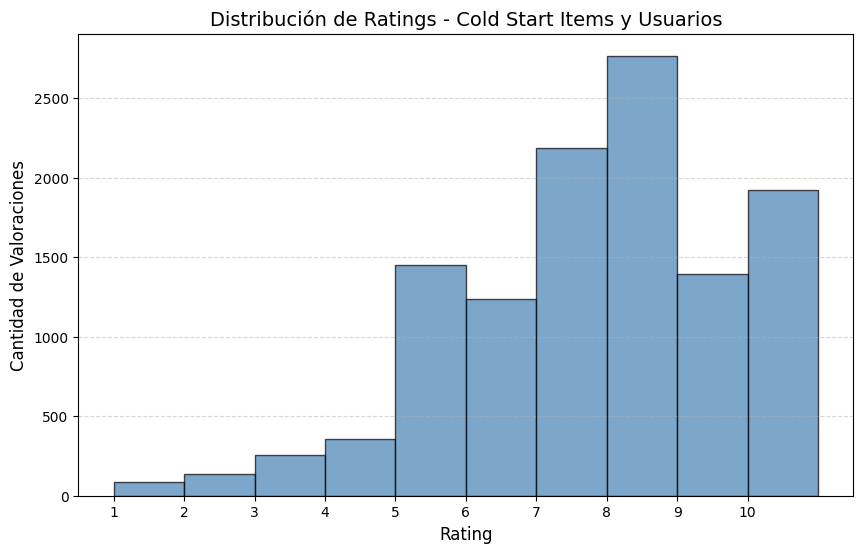

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(df_onlyonly['rating'].to_list(), bins=range(int(df_onlyonly['rating'].min()), int(df_onlyonly['rating'].max()) + 2), edgecolor='black', alpha=0.7, color='steelblue')

plt.title('Distribución de Ratings - Cold Start Items y Usuarios', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Cantidad de Valoraciones', fontsize=12)
plt.xticks(range(int(df_onlyonly['rating'].min()), int(df_onlyonly['rating'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

La nota óptima empírica para minimizar el MAE es: 8.00
La mediana del dataset es: 8.00
El MAE mínimo conseguido es: 1.5577


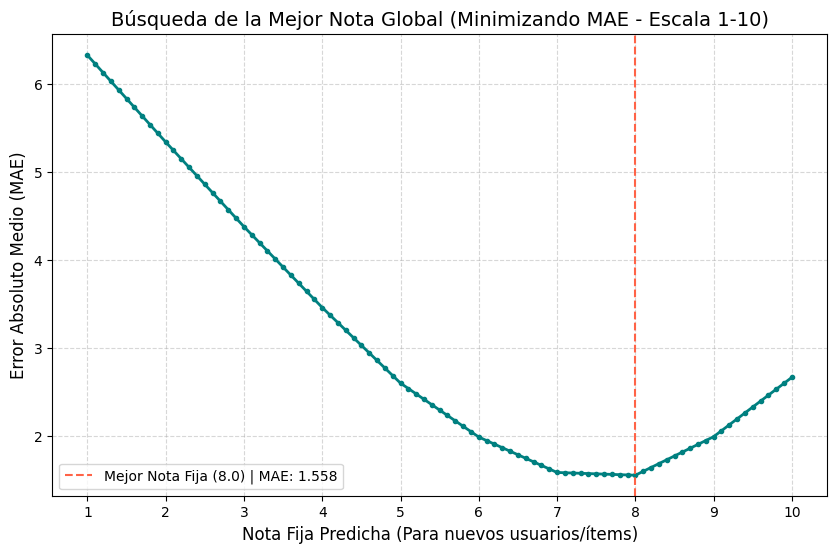

In [35]:
# Ajustado para valoraciones del 1 al 10 (con saltos de 0.1 para mayor precisión)
notas_posibles = np.arange(1.0, 10.1, 0.1)

# Extraemos la columna de valoraciones reales a un array de numpy para que sea rapidísimo
valoraciones_reales = df_onlyonly['rating'].to_numpy()

# Lista para guardar los resultados del error
maes = []

# Iteramos probando qué pasaría si a TODOS les pusiéramos la misma nota
for nota_fija in notas_posibles:
    # Calculamos el MAE: Media del valor absoluto de la diferencia entre la predicción y la realidad
    mae_actual = np.mean(np.abs(valoraciones_reales - nota_fija))
    maes.append(mae_actual)

# Encontramos la nota que nos dio el menor error
min_mae = min(maes)
mejor_nota = notas_posibles[maes.index(min_mae)]

# Comprobación teórica: La mediana
mediana_real = np.median(valoraciones_reales)

print(f"La nota óptima empírica para minimizar el MAE es: {mejor_nota:.2f}")
print(f"La mediana del dataset es: {mediana_real:.2f}")
print(f"El MAE mínimo conseguido es: {min_mae:.4f}")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))

plt.plot(notas_posibles, maes, marker='.', linestyle='-', color='teal', linewidth=2)

# Marcamos el punto más bajo (nuestro óptimo)
plt.axvline(mejor_nota, color='tomato', linestyle='--', 
            label=f'Mejor Nota Fija ({mejor_nota:.1f}) | MAE: {min_mae:.3f}')

plt.title('Búsqueda de la Mejor Nota Global (Minimizando MAE - Escala 1-10)', fontsize=14)
plt.xlabel('Nota Fija Predicha (Para nuevos usuarios/ítems)', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE)', fontsize=12)

# Forzamos que los ticks del eje X vayan del 1 al 10 de uno en uno para mayor claridad
plt.xticks(range(1, 11))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## Usuario nuevo, item con valoraciones previas

In [38]:
df_newuser_manyitem = duckdb.sql("""
    SELECT *
    FROM df 
    WHERE item IN (
        SELECT item
        FROM (
            SELECT item, count(*) AS num_ratings
            FROM df
            GROUP BY item
            HAVING num_ratings > 1
            )
    ) and user IN (
        SELECT user
        FROM (
            SELECT user, count(*) AS num_ratings
            FROM df
            GROUP BY user
            HAVING num_ratings < 2
            )
    )
""").pl()
df_newuser_manyitem

user,item,rating
i64,i64,f64
25359,60513,7.0
25361,33155,8.0
25362,827,10.0
25363,74932,7.0
25372,38488,7.0
…,…,…
71202,157385,10.0
71207,2664,8.0
71211,295,4.0


In [43]:
duckdb.sql("""
    SELECT item, AVG(rating) AS avg_rating, COUNT(*) AS num_ratings, mode(rating) AS mode_rating, median(rating) AS median_rating, STDDEV(rating) AS std_dev_rating
    FROM df 
    WHERE item IN (SELECT item FROM df_newuser_manyitem)
    GROUP BY item
""").pl()

item,avg_rating,num_ratings,mode_rating,median_rating,std_dev_rating
i64,f64,i64,f64,f64,f64
26234,7.940299,134,8.0,8.0,1.407612
35036,7.7,10,7.0,7.5,2.110819
35044,7.714286,7,8.0,8.0,1.704336
28134,7.458333,24,8.0,8.0,1.641292
35308,8.064516,31,10.0,8.0,1.569193
…,…,…,…,…,…
125967,8.5,2,10.0,8.5,2.12132
104499,9.0,2,8.0,9.0,1.414214
121386,8.5,2,8.0,8.5,0.707107


In [59]:
df_new_user_compare = duckdb.sql("""
    SELECT subquery.*, df_newuser_manyitem.rating AS newuser_rating
    FROM (
        SELECT df.item, AVG(df.rating) AS avg_rating, COUNT(*) AS num_ratings, mode(df.rating) AS mode_rating, median(df.rating) AS median_rating, STDDEV(df.rating) AS std_dev_rating
        FROM df
        WHERE df.item IN (SELECT item FROM df_newuser_manyitem) 
        GROUP BY df.item
    ) as subquery
    LEFT JOIN df_newuser_manyitem ON subquery.item = df_newuser_manyitem.item
""").pl()
df_new_user_compare.head(5)

item,avg_rating,num_ratings,mode_rating,median_rating,std_dev_rating,newuser_rating
i64,f64,i64,f64,f64,f64,f64
113508,7.0,2,6.0,7.0,1.414214,6.0
9143,6.875,8,6.0,6.5,1.807722,8.0
27404,7.109091,55,8.0,7.0,1.696104,6.0
5819,6.75,4,8.0,7.0,1.5,6.0
44463,7.0,5,5.0,5.0,2.738613,10.0


--- RESULTADOS DE LAS MÉTRICAS ---
Media   -> MAE: 1.157 | RMSE: 1.513
Mediana -> MAE: 1.101 | RMSE: 1.579
Moda    -> MAE: 1.228 | RMSE: 1.903
--------------------------------


C:\Users\rahar\AppData\Local\Temp\ipykernel_19076\3793296561.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(errores, labels=estrategias, patch_artist=True,


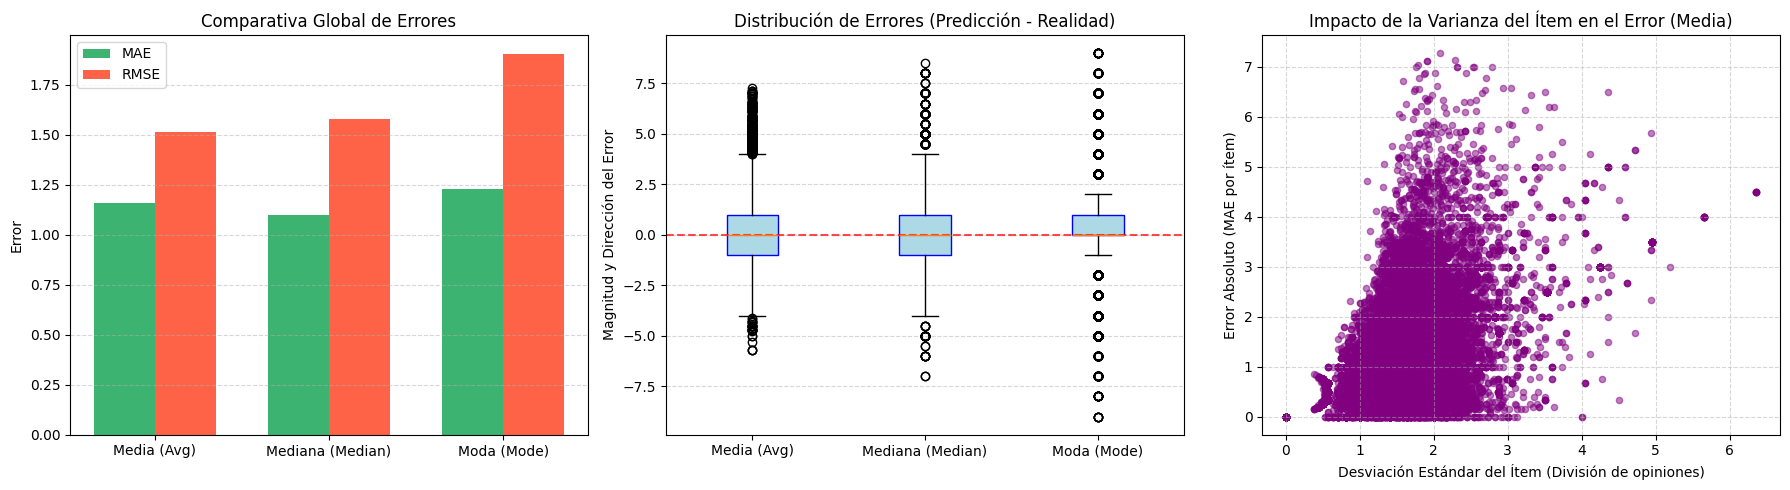

In [60]:
# 1. CÁLCULO DE MÉTRICAS (MAE y RMSE)
# Calculamos los errores absolutos y cuadráticos para cada estrategia
df_eval = df_new_user_compare.with_columns([
    # Errores Absolutos (para MAE)
    (pl.col('avg_rating') - pl.col('newuser_rating')).abs().alias('abs_err_avg'),
    (pl.col('median_rating') - pl.col('newuser_rating')).abs().alias('abs_err_median'),
    (pl.col('mode_rating') - pl.col('newuser_rating')).abs().alias('abs_err_mode'),
    
    # Errores (con signo) para ver sesgos (sobrepredicción vs subpredicción)
    (pl.col('avg_rating') - pl.col('newuser_rating')).alias('err_avg'),
    (pl.col('median_rating') - pl.col('newuser_rating')).alias('err_median'),
    (pl.col('mode_rating') - pl.col('newuser_rating')).alias('err_mode'),
    
    # Errores Cuadráticos (para RMSE)
    ((pl.col('avg_rating') - pl.col('newuser_rating'))**2).alias('sq_err_avg'),
    ((pl.col('median_rating') - pl.col('newuser_rating'))**2).alias('sq_err_median'),
    ((pl.col('mode_rating') - pl.col('newuser_rating'))**2).alias('sq_err_mode')
])

# Agregamos para obtener las métricas finales
metrics = df_eval.select([
    pl.col('abs_err_avg').mean().alias('MAE_Avg'),
    pl.col('abs_err_median').mean().alias('MAE_Median'),
    pl.col('abs_err_mode').mean().alias('MAE_Mode'),
    
    (pl.col('sq_err_avg').mean() ** 0.5).alias('RMSE_Avg'),
    (pl.col('sq_err_median').mean() ** 0.5).alias('RMSE_Median'),
    (pl.col('sq_err_mode').mean() ** 0.5).alias('RMSE_Mode')
]).to_dict(as_series=False)

print("--- RESULTADOS DE LAS MÉTRICAS ---")
print(f"Media   -> MAE: {metrics['MAE_Avg'][0]:.3f} | RMSE: {metrics['RMSE_Avg'][0]:.3f}")
print(f"Mediana -> MAE: {metrics['MAE_Median'][0]:.3f} | RMSE: {metrics['RMSE_Median'][0]:.3f}")
print(f"Moda    -> MAE: {metrics['MAE_Mode'][0]:.3f} | RMSE: {metrics['RMSE_Mode'][0]:.3f}")
print("-" * 32)

# ==========================================
# 2. VISUALIZACIONES SIGNIFICATIVAS
# ==========================================

estrategias = ['Media (Avg)', 'Mediana (Median)', 'Moda (Mode)']
maes = [metrics['MAE_Avg'][0], metrics['MAE_Median'][0], metrics['MAE_Mode'][0]]
rmses = [metrics['RMSE_Avg'][0], metrics['RMSE_Median'][0], metrics['RMSE_Mode'][0]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: Comparativa de MAE y RMSE ---
# ¿Qué nos dice? Cuál es el ganador absoluto a nivel global.
x = np.arange(len(estrategias))
width = 0.35

axes[0].bar(x - width/2, maes, width, label='MAE', color='mediumseagreen')
axes[0].bar(x + width/2, rmses, width, label='RMSE', color='tomato')
axes[0].set_ylabel('Error')
axes[0].set_title('Comparativa Global de Errores', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(estrategias)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- GRÁFICO 2: Distribución del Error (Boxplot) ---
# ¿Qué nos dice? Si alguna métrica tiende a ser demasiado optimista (sobrepredecir) 
# o pesimista, y cómo de grandes son sus valores atípicos.
errores = [
    df_eval['err_avg'].to_list(),
    df_eval['err_median'].to_list(),
    df_eval['err_mode'].to_list()
]

axes[1].boxplot(errores, labels=estrategias, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='blue'))
axes[1].axhline(0, color='red', linestyle='--', alpha=0.7) # Línea de error CERO
axes[1].set_title('Distribución de Errores (Predicción - Realidad)', fontsize=12)
axes[1].set_ylabel('Magnitud y Dirección del Error')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- GRÁFICO 3: Error de la Media vs Incertidumbre (Desviación Estándar) ---
# ¿Qué nos dice? Si los ítems divisivos (alta std_dev) hacen que nos equivoquemos más.
x_std = df_eval['std_dev_rating'].to_list()
y_err_abs = df_eval['abs_err_avg'].to_list() # Usamos la media como ejemplo

axes[2].scatter(x_std, y_err_abs, alpha=0.5, color='purple', s=20)
axes[2].set_title('Impacto de la Varianza del Ítem en el Error (Media)', fontsize=12)
axes[2].set_xlabel('Desviación Estándar del Ítem (División de opiniones)')
axes[2].set_ylabel('Error Absoluto (MAE por ítem)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Todo: Dividir entre duficientes ratins o no

# Usuarios con historia pero nuevos items

In [64]:
df_many_newitem = duckdb.sql("""
    SELECT *
    FROM df 
    WHERE item IN (
        SELECT item
        FROM (
            SELECT item, count(*) AS num_ratings
            FROM df
            GROUP BY item
            HAVING num_ratings < 2
            )
    ) and user IN (
        SELECT user
        FROM (
            SELECT user, count(*) AS num_ratings
            FROM df
            GROUP BY user
            HAVING num_ratings > 1
            )
    )
""").pl()
df_many_newitem.head(5)
    

user,item,rating
i64,i64,f64
22311,67415,9.0
22311,67416,9.0
22311,67417,10.0
22311,67418,9.0
22311,67419,9.0


In [66]:
df_new_user_compare = duckdb.sql("""
    SELECT subquery.*, df_many_newitem.rating AS newitem_rating
    FROM (
        SELECT df.user, AVG(df.rating) AS avg_rating, COUNT(*) AS num_ratings, mode(df.rating) AS mode_rating, median(df.rating) AS median_rating, STDDEV(df.rating) AS std_dev_rating
        FROM df
        WHERE df.item NOT IN (SELECT item FROM df_many_newitem) 
        GROUP BY df.user
    ) as subquery
    LEFT JOIN df_many_newitem ON subquery.user = df_many_newitem.user
""").pl()
df_new_user_compare.head(5)

user,avg_rating,num_ratings,mode_rating,median_rating,std_dev_rating,newitem_rating
i64,f64,i64,f64,f64,f64,f64
27579,6.6,5,5.0,6.0,1.81659,8.0
27579,6.6,5,5.0,6.0,1.81659,9.0
27579,6.6,5,5.0,6.0,1.81659,7.0
27579,6.6,5,5.0,6.0,1.81659,7.0
27589,7.714286,7,8.0,8.0,1.976047,9.0


--- RESULTADOS: ESTRATEGIAS BASADAS EN EL USUARIO ---
Media Histórica del Usuario   -> MAE: 1.284 | RMSE: 1.724
Mediana Histórica del Usuario -> MAE: 1.254 | RMSE: 1.815
Moda Histórica del Usuario    -> MAE: 1.371 | RMSE: 2.028
-------------------------------------------------------


C:\Users\rahar\AppData\Local\Temp\ipykernel_19076\738583059.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(errores, labels=estrategias, patch_artist=True,


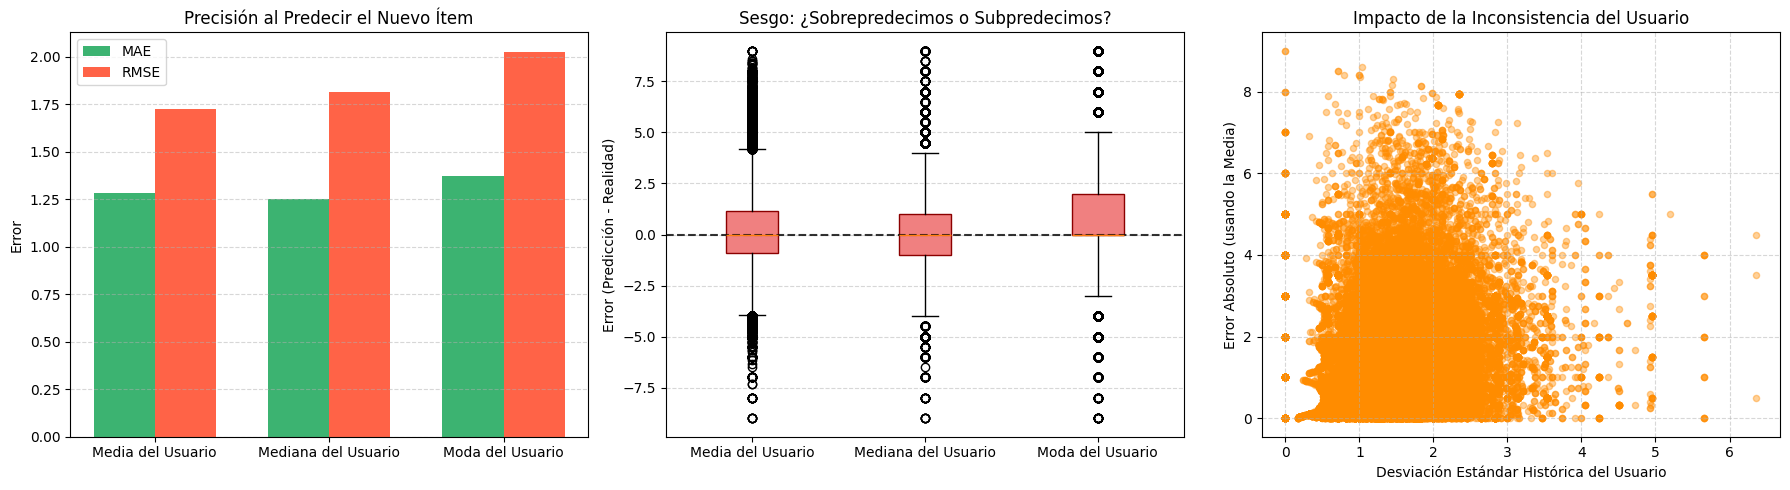

In [67]:
# 1. CÁLCULO DE MÉTRICAS (MAE y RMSE)
# Asumiendo que tu dataframe se llama df_new_user_compare
df_eval = df_new_user_compare.with_columns([
    # Errores Absolutos (para MAE)
    (pl.col('avg_rating') - pl.col('newitem_rating')).abs().alias('abs_err_avg'),
    (pl.col('median_rating') - pl.col('newitem_rating')).abs().alias('abs_err_median'),
    (pl.col('mode_rating') - pl.col('newitem_rating')).abs().alias('abs_err_mode'),
    
    # Errores (con signo) para ver sesgos del usuario
    (pl.col('avg_rating') - pl.col('newitem_rating')).alias('err_avg'),
    (pl.col('median_rating') - pl.col('newitem_rating')).alias('err_median'),
    (pl.col('mode_rating') - pl.col('newitem_rating')).alias('err_mode'),
    
    # Errores Cuadráticos (para RMSE)
    ((pl.col('avg_rating') - pl.col('newitem_rating'))**2).alias('sq_err_avg'),
    ((pl.col('median_rating') - pl.col('newitem_rating'))**2).alias('sq_err_median'),
    ((pl.col('mode_rating') - pl.col('newitem_rating'))**2).alias('sq_err_mode')
])

# Agregamos para obtener las métricas globales de nuestras heurísticas
metrics = df_eval.select([
    pl.col('abs_err_avg').mean().alias('MAE_Avg'),
    pl.col('abs_err_median').mean().alias('MAE_Median'),
    pl.col('abs_err_mode').mean().alias('MAE_Mode'),
    
    (pl.col('sq_err_avg').mean() ** 0.5).alias('RMSE_Avg'),
    (pl.col('sq_err_median').mean() ** 0.5).alias('RMSE_Median'),
    (pl.col('sq_err_mode').mean() ** 0.5).alias('RMSE_Mode')
]).to_dict(as_series=False)

print("--- RESULTADOS: ESTRATEGIAS BASADAS EN EL USUARIO ---")
print(f"Media Histórica del Usuario   -> MAE: {metrics['MAE_Avg'][0]:.3f} | RMSE: {metrics['RMSE_Avg'][0]:.3f}")
print(f"Mediana Histórica del Usuario -> MAE: {metrics['MAE_Median'][0]:.3f} | RMSE: {metrics['RMSE_Median'][0]:.3f}")
print(f"Moda Histórica del Usuario    -> MAE: {metrics['MAE_Mode'][0]:.3f} | RMSE: {metrics['RMSE_Mode'][0]:.3f}")
print("-" * 55)

# ==========================================
# 2. VISUALIZACIONES SIGNIFICATIVAS
# ==========================================

estrategias = ['Media del Usuario', 'Mediana del Usuario', 'Moda del Usuario']
maes = [metrics['MAE_Avg'][0], metrics['MAE_Median'][0], metrics['MAE_Mode'][0]]
rmses = [metrics['RMSE_Avg'][0], metrics['RMSE_Median'][0], metrics['RMSE_Mode'][0]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: Comparativa Global de MAE y RMSE ---
x = np.arange(len(estrategias))
width = 0.35

axes[0].bar(x - width/2, maes, width, label='MAE', color='mediumseagreen')
axes[0].bar(x + width/2, rmses, width, label='RMSE', color='tomato')
axes[0].set_ylabel('Error')
axes[0].set_title('Precisión al Predecir el Nuevo Ítem', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(estrategias)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- GRÁFICO 2: Distribución del Error (Sesgo del Usuario) ---
# Extraemos listas manejando posibles nulos si la moda falló
errores = [
    df_eval['err_avg'].drop_nulls().to_list(),
    df_eval['err_median'].drop_nulls().to_list(),
    df_eval['err_mode'].drop_nulls().to_list()
]

axes[1].boxplot(errores, labels=estrategias, patch_artist=True,
                boxprops=dict(facecolor='lightcoral', color='darkred'))
axes[1].axhline(0, color='black', linestyle='--', alpha=0.8) 
axes[1].set_title('Sesgo: ¿Sobrepredecimos o Subpredecimos?', fontsize=12)
axes[1].set_ylabel('Error (Predicción - Realidad)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- GRÁFICO 3: Inconsistencia del Usuario vs Error ---
# Aquí std_dev_rating representa qué tan errático es el USUARIO votando
x_std = df_eval['std_dev_rating'].to_list()
y_err_abs = df_eval['abs_err_avg'].to_list() 

axes[2].scatter(x_std, y_err_abs, alpha=0.4, color='darkorange', s=20)
axes[2].set_title('Impacto de la Inconsistencia del Usuario', fontsize=12)
axes[2].set_xlabel('Desviación Estándar Histórica del Usuario')
axes[2].set_ylabel('Error Absoluto (usando la Media)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()